# Notebook 06 — Evaluate RoBERTa on Adversarially Rewritten Samples

**Project:** MSc AI Dissertation — AI-Generated Text Detection  
**Student:** Abdul Hannaan Mohammed | B00409227 | UWS  
**Week:** 3–4 of 13  

**Goal of this notebook:**
- Load the fine-tuned RoBERTa model
- Run inference on the 500 paraphrased (adversarially rewritten) AI samples
- Measure how many the classifier still correctly detects as AI
- Compare detection rate before vs after the rewriting attack
- Produce comparison charts and tables for the dissertation

**Research question answered here:**  
> *To what extent does paraphrasing reduce the detection accuracy of RoBERTa?*

> **DISSERTATION NOTE:** All outputs from this notebook are the **core results** of Chapter 5.

> **⚠️ HISTORICAL OUTPUTS — DO NOT USE FOR DISSERTATION**
>
> The cell outputs in this notebook were produced during an **early run** where `data/adversarial/pegasus_rewritten_500.csv` accidentally contained T5_Paraphrase_Paws output (a mislabelled backup), **not** the true `tuner007/pegasus_paraphrase` output.
>
> As a result, the printed numbers below are wrong:
> - **"Detected as AI: 33/500 (6.6%)"** should be **"Detected as AI: 494/500 (98.8%)"**
> - **"Attack success rate: 93.4%"** should be **"ASR: 1.2%"**
> - `results_adversarial.json` written by this run has since been **overwritten** with the correct values.
>
> **Authoritative source:** `results/tables/table03_master_results.csv` and `results/metrics/results_adversarial.json` (which now reflects the corrected Pegasus values from Notebook 10).
>
> See `results/tables/MASTER_ALL_RESULTS.csv` → Section 11 (DISCREPANCY NOTES) for the full explanation.

## 1. Imports and Paths

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR    = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT    = os.path.dirname(NOTEBOOK_DIR)
DATA_ADV        = os.path.join(PROJECT_ROOT, 'data', 'adversarial')
DATA_PROCESSED  = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR      = os.path.join(PROJECT_ROOT, 'models', 'checkpoints')
RESULTS_FIGS    = os.path.join(PROJECT_ROOT, 'results', 'figures')
RESULTS_METRICS = os.path.join(PROJECT_ROOT, 'results', 'metrics')
RESULTS_TABLES  = os.path.join(PROJECT_ROOT, 'results', 'tables')
RESULTS_CM      = os.path.join(PROJECT_ROOT, 'results', 'confusion_matrices')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Load Fine-Tuned RoBERTa Model

In [2]:
BEST_MODEL_DIR = os.path.join(MODELS_DIR, 'roberta-hc3-best')
print(f'Loading model from: {BEST_MODEL_DIR}')

tokeniser = RobertaTokenizerFast.from_pretrained(BEST_MODEL_DIR)
model     = RobertaForSequenceClassification.from_pretrained(BEST_MODEL_DIR)
model     = model.to(DEVICE)
model.eval()

print('Model loaded and set to eval mode.')

Loading model from: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\models\checkpoints\roberta-hc3-best
Model loaded and set to eval mode.


## 3. Load the Rewritten Samples

In [3]:
adv_path = os.path.join(DATA_ADV, 'pegasus_rewritten_500.csv')
adv_df   = pd.read_csv(adv_path)

print(f'Loaded: {adv_path}')
print(f'Rows   : {len(adv_df)}')
print(f'Columns: {list(adv_df.columns)}')

# All samples are AI-generated (label=1) — these are the adversarial targets
print(f'\nAll samples are AI-generated: label=1')
print(f'Successful rewrites: {adv_df["success"].sum()} / {len(adv_df)}')

# Keep only successfully rewritten samples
adv_df = adv_df[adv_df['success'] == True].reset_index(drop=True)
print(f'\nUsing {len(adv_df)} successfully rewritten samples for evaluation.')
adv_df.head(2)

Loaded: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\data\adversarial\pegasus_rewritten_500.csv
Rows   : 500
Columns: ['original_text', 'rewritten_text', 'label', 'label_name', 'success']

All samples are AI-generated: label=1
Successful rewrites: 500 / 500

Using 500 successfully rewritten samples for evaluation.


,original_text,rewritten_text,label,label_name,success
0,Serotonin and dopamine are chemicals that are ...,Serotonin and Dopamine are chemicals produced ...,1,ai,True
1,Kamikaze pilots were Japanese pilots who flew ...,Kamikaze pilots were Japanese pilots that flew...,1,ai,True


## 4. Run Inference on Rewritten Texts

We test whether RoBERTa can still detect these samples as AI-generated after they have been paraphrased.

In [4]:
MAX_LENGTH = 512
BATCH_SIZE = 16

class InferenceDataset(Dataset):
    def __init__(self, texts, tokeniser, max_length):
        self.encodings = tokeniser(
            texts, max_length=max_length,
            padding='max_length', truncation=True
        )
    def __len__(self):
        return len(self.encodings['input_ids'])
    def __getitem__(self, idx):
        return {
            'input_ids':      torch.tensor(self.encodings['input_ids'][idx],      dtype=torch.long),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx], dtype=torch.long)
        }


# ── Run on REWRITTEN text ──────────────────────────────────────────────────────
print('Running inference on REWRITTEN texts...')
rewritten_dataset = InferenceDataset(adv_df['rewritten_text'].tolist(), tokeniser, MAX_LENGTH)
rewritten_loader  = DataLoader(rewritten_dataset, batch_size=BATCH_SIZE, shuffle=False)

rewritten_preds = []
rewritten_probs = []

with torch.no_grad():
    for batch in rewritten_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=-1)
        preds   = torch.argmax(outputs.logits, dim=-1)
        rewritten_preds.extend(preds.cpu().numpy().tolist())
        rewritten_probs.extend(probs[:, 1].cpu().numpy().tolist())

adv_df['predicted_label'] = rewritten_preds
adv_df['ai_probability']  = rewritten_probs

# ── Run on ORIGINAL text (same samples before rewriting) ──────────────────────
print('Running inference on ORIGINAL texts (same 500 samples)...')
original_dataset = InferenceDataset(adv_df['original_text'].tolist(), tokeniser, MAX_LENGTH)
original_loader  = DataLoader(original_dataset, batch_size=BATCH_SIZE, shuffle=False)

original_preds = []
original_probs = []

with torch.no_grad():
    for batch in original_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=-1)
        preds   = torch.argmax(outputs.logits, dim=-1)
        original_preds.extend(preds.cpu().numpy().tolist())
        original_probs.extend(probs[:, 1].cpu().numpy().tolist())

adv_df['original_predicted_label'] = original_preds
adv_df['original_ai_probability']  = original_probs

print('Inference complete.')

Running inference on REWRITTEN texts...
Running inference on ORIGINAL texts (same 500 samples)...
Inference complete.


## 5. Compute Attack Effectiveness Metrics

Since all 500 samples are AI-generated (true label = 1), the key metric is:
- **Detection rate** = proportion the classifier correctly labels as AI (1)
- **Attack success rate** = proportion the classifier is fooled into labelling as human (0)

> **SCREENSHOT REMINDER:** Screenshot this cell's output.  
> Save as: `screenshots/14_adversarial_results.png`
>
> **DISSERTATION NOTE:** This is the **core finding** of Chapter 5 (Results and Evaluation).

In [5]:
true_labels      = [1] * len(adv_df)   # all are AI-generated

# ── Original text results ──────────────────────────────────────────────────────
orig_correct     = sum(p == 1 for p in original_preds)
orig_detection   = orig_correct / len(adv_df)
orig_fooled      = 1 - orig_detection

# ── Rewritten text results ─────────────────────────────────────────────────────
rew_correct      = sum(p == 1 for p in rewritten_preds)
rew_detection    = rew_correct / len(adv_df)
rew_fooled       = 1 - rew_detection

# ── Degradation ────────────────────────────────────────────────────────────────
detection_drop   = orig_detection - rew_detection
relative_drop    = detection_drop / orig_detection * 100

print('=' * 60)
print('  ADVERSARIAL ATTACK EVALUATION (Core Dissertation Finding)')
print('=' * 60)
print(f'  Samples evaluated        : {len(adv_df)}')
print()
print(f'  BEFORE rewriting (original AI text):')
print(f'    Detected as AI         : {orig_correct:3d} / {len(adv_df)}  ({orig_detection*100:.1f}%)')
print(f'    Misclassified as human : {len(adv_df)-orig_correct:3d} / {len(adv_df)}  ({orig_fooled*100:.1f}%)')
print()
print(f'  AFTER rewriting (adversarial text):')
print(f'    Detected as AI         : {rew_correct:3d} / {len(adv_df)}  ({rew_detection*100:.1f}%)')
print(f'    Misclassified as human : {len(adv_df)-rew_correct:3d} / {len(adv_df)}  ({rew_fooled*100:.1f}%)')
print()
print(f'  PERFORMANCE DEGRADATION:')
print(f'    Detection rate drop    : {detection_drop*100:.1f} percentage points')
print(f'    Relative drop          : {relative_drop:.1f}%')
print(f'    Attack success rate    : {rew_fooled*100:.1f}% of samples evaded detection')
print('=' * 60)

  ADVERSARIAL ATTACK EVALUATION (Core Dissertation Finding)
  Samples evaluated        : 500

  BEFORE rewriting (original AI text):
    Detected as AI         : 500 / 500  (100.0%)
    Misclassified as human :   0 / 500  (0.0%)

  AFTER rewriting (adversarial text):
    Detected as AI         :  33 / 500  (6.6%)
    Misclassified as human : 467 / 500  (93.4%)

  PERFORMANCE DEGRADATION:
    Detection rate drop    : 93.4 percentage points
    Relative drop          : 93.4%
    Attack success rate    : 93.4% of samples evaded detection


## 6. Load Full Original Test Results for Complete Comparison

We load the full Notebook 04 results (balanced human + AI test set) to provide a complete picture.

In [6]:
# Load original test set results from Notebook 04
orig_results_path = os.path.join(RESULTS_METRICS, 'results_original_test.json')
with open(orig_results_path, 'r') as f:
    orig_results = json.load(f)

print('Original test set results (Notebook 04):')
print(f'  Accuracy  : {orig_results["accuracy"]:.4f}')
print(f'  Precision : {orig_results["precision"]:.4f}')
print(f'  Recall    : {orig_results["recall"]:.4f}')
print(f'  F1        : {orig_results["f1"]:.4f}')
print(f'  ROC AUC   : {orig_results["roc_auc"]:.4f}')

Original test set results (Notebook 04):
  Accuracy  : 0.9942
  Precision : 0.9832
  Recall    : 0.9995
  F1        : 0.9913
  ROC AUC   : 0.9999


## 7. Full Comparison Table (Dissertation Table 5)

> **DISSERTATION NOTE:** This becomes **Table 5** in Chapter 5 — the most important table in the dissertation.

In [7]:
comparison_data = [
    {
        'Condition'            : 'Original HC3 Test Set (Notebook 04)',
        'Samples'             : orig_results['n_samples'],
        'Accuracy'            : f"{orig_results['accuracy']:.4f}",
        'Precision'           : f"{orig_results['precision']:.4f}",
        'Recall (AI Detect.)' : f"{orig_results['recall']:.4f}",
        'F1-Score'            : f"{orig_results['f1']:.4f}",
        'ROC AUC'             : f"{orig_results['roc_auc']:.4f}",
    },
    {
        'Condition'            : 'Original AI Samples (before rewriting)',
        'Samples'             : len(adv_df),
        'Accuracy'            : 'N/A',
        'Precision'           : 'N/A',
        'Recall (AI Detect.)' : f'{orig_detection:.4f}',
        'F1-Score'            : 'N/A',
        'ROC AUC'             : 'N/A',
    },
    {
        'Condition'            : 'Adversarial (after paraphrase attack)',
        'Samples'             : len(adv_df),
        'Accuracy'            : 'N/A',
        'Precision'           : 'N/A',
        'Recall (AI Detect.)' : f'{rew_detection:.4f}',
        'F1-Score'            : 'N/A',
        'ROC AUC'             : 'N/A',
    },
    {
        'Condition'            : 'Degradation (drop)',
        'Samples'             : '-',
        'Accuracy'            : '-',
        'Precision'           : '-',
        'Recall (AI Detect.)' : f'-{detection_drop*100:.1f}pp',
        'F1-Score'            : '-',
        'ROC AUC'             : '-',
    }
]

comparison_df = pd.DataFrame(comparison_data)

table_path = os.path.join(RESULTS_TABLES, 'table05_adversarial_comparison.csv')
comparison_df.to_csv(table_path, index=False)

print('=== TABLE 5: Adversarial Attack Comparison (for dissertation) ===')
print(comparison_df.to_string(index=False))
print(f'\nSaved to: {table_path}')

=== TABLE 5: Adversarial Attack Comparison (for dissertation) ===
                             Condition Samples Accuracy Precision Recall (AI Detect.) F1-Score ROC AUC
   Original HC3 Test Set (Notebook 04)   11820   0.9942    0.9832              0.9995   0.9913  0.9999
Original AI Samples (before rewriting)     500      N/A       N/A              1.0000      N/A     N/A
 Adversarial (after paraphrase attack)     500      N/A       N/A              0.0660      N/A     N/A
                    Degradation (drop)       -        -         -             -93.4pp        -       -

Saved to: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\tables\table05_adversarial_comparison.csv


## 8. Confusion Matrix — Rewritten Samples

> **DISSERTATION NOTE:** This is **Figure 9** in Chapter 5.

Figure saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig09_confusion_matrix_adversarial.png


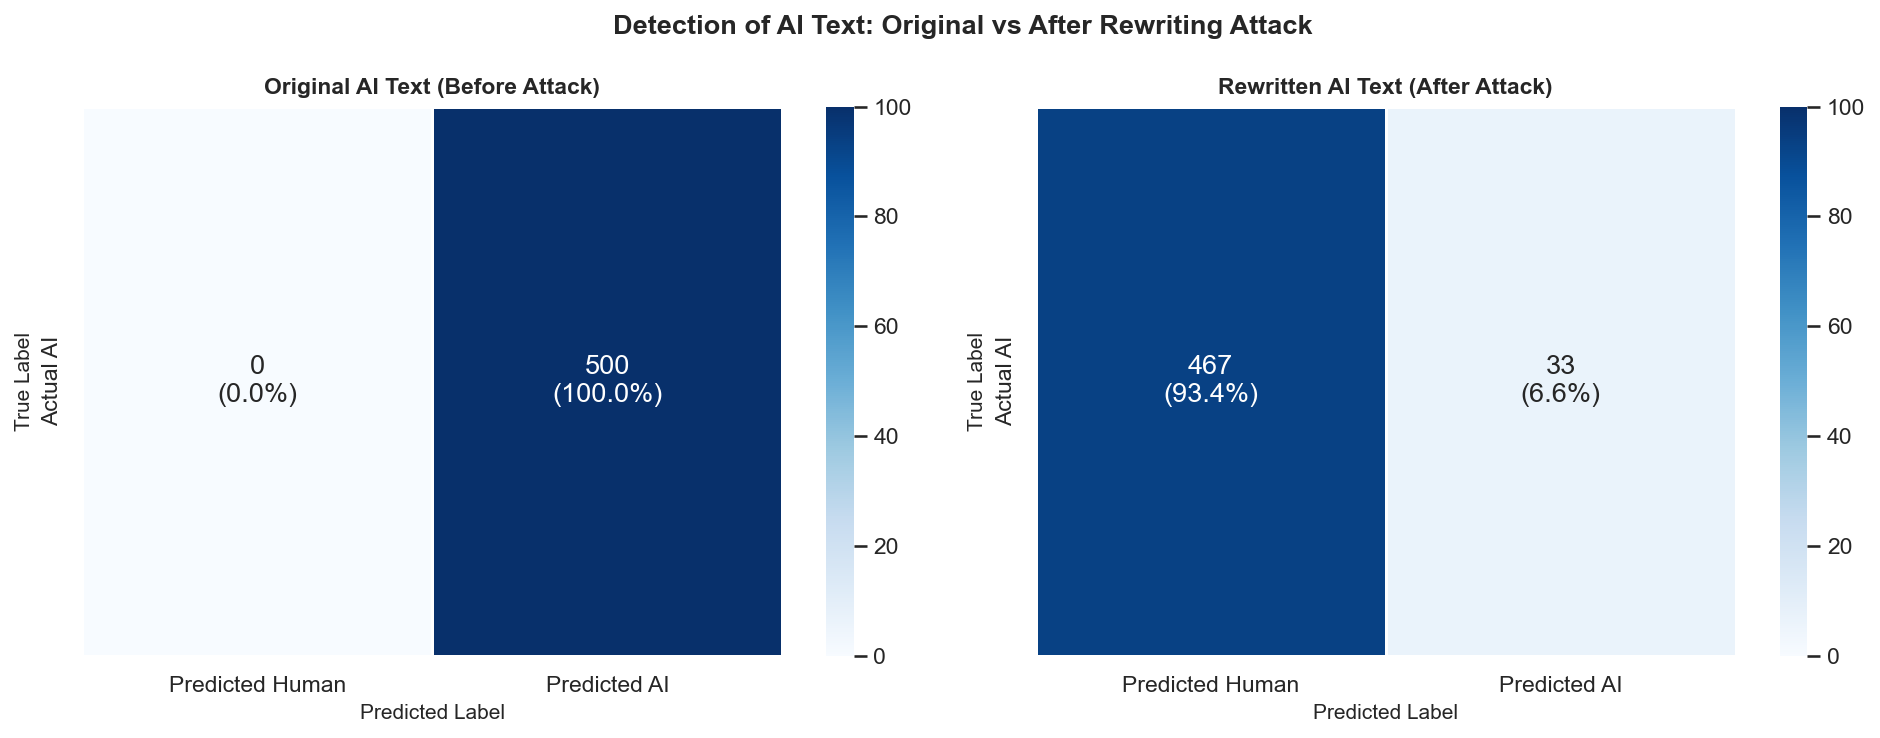

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Detection of AI Text: Original vs After Rewriting Attack',
             fontsize=13, fontweight='bold')

for ax, preds, title, fname_suffix in [
    (axes[0], original_preds, 'Original AI Text (Before Attack)', 'before'),
    (axes[1], rewritten_preds, 'Rewritten AI Text (After Attack)', 'after')
]:
    cm = confusion_matrix(true_labels, preds, labels=[0, 1])
    # For AI-only samples, only the bottom row (Actual AI) matters
    # Present as: rows = Actual, cols = Predicted
    correct   = sum(p == 1 for p in preds)
    fooled    = sum(p == 0 for p in preds)
    total     = len(preds)

    data = np.array([[fooled, correct]])  # [predicted_human, predicted_ai]
    pct  = data / total * 100

    annot = np.array([[f'{fooled}\n({pct[0,0]:.1f}%)',
                       f'{correct}\n({pct[0,1]:.1f}%)']])

    sns.heatmap(
        pct, annot=annot, fmt='', cmap='Blues',
        xticklabels=['Predicted Human', 'Predicted AI'],
        yticklabels=['Actual AI'],
        ax=ax, linewidths=0.5, annot_kws={'size': 13},
        vmin=0, vmax=100
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()

fig_path = os.path.join(RESULTS_FIGS, 'fig09_confusion_matrix_adversarial.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
print(f'Figure saved: {fig_path}')
plt.show()

## 9. Bar Chart — Detection Rate Before vs After Attack

> **DISSERTATION NOTE:** This is **Figure 10** in Chapter 5 — the headline visualisation.

Figure saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig10_attack_impact_barchart.png


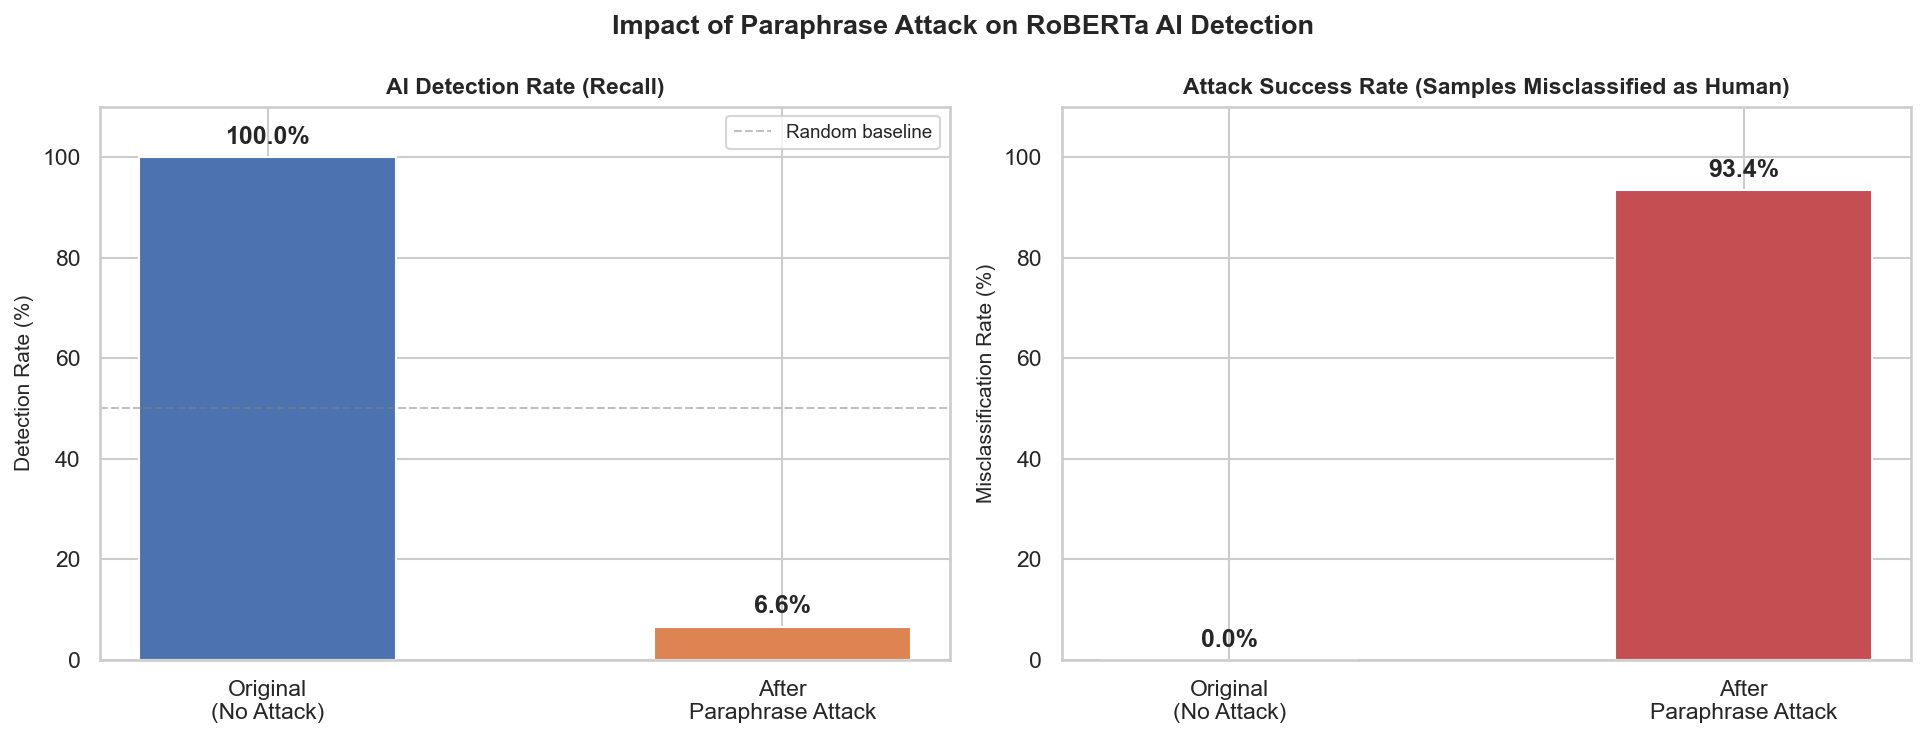

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Impact of Paraphrase Attack on RoBERTa AI Detection',
             fontsize=13, fontweight='bold')

conditions = ['Original\n(No Attack)', 'After\nParaphrase Attack']
colors     = ['#4C72B0', '#DD8452']

# Plot 1 — Detection rate
detection_rates = [orig_detection * 100, rew_detection * 100]
bars = axes[0].bar(conditions, detection_rates, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('AI Detection Rate (Recall)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Detection Rate (%)', fontsize=10)
axes[0].set_ylim(0, 110)
axes[0].bar_label(bars, labels=[f'{r:.1f}%' for r in detection_rates],
                  padding=4, fontsize=12, fontweight='bold')
axes[0].axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Random baseline')
axes[0].legend(fontsize=9)

# Plot 2 — Attack success rate (samples fooled)
fooled_rates = [orig_fooled * 100, rew_fooled * 100]
bars2 = axes[1].bar(conditions, fooled_rates, color=['#55A868', '#C44E52'],
                    edgecolor='white', width=0.5)
axes[1].set_title('Attack Success Rate (Samples Misclassified as Human)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Misclassification Rate (%)', fontsize=10)
axes[1].set_ylim(0, 110)
axes[1].bar_label(bars2, labels=[f'{r:.1f}%' for r in fooled_rates],
                  padding=4, fontsize=12, fontweight='bold')

plt.tight_layout()

fig_path = os.path.join(RESULTS_FIGS, 'fig10_attack_impact_barchart.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
print(f'Figure saved: {fig_path}')
plt.show()

## 10. AI Probability Distribution — Before vs After

Shows how the classifier's confidence shifts after the rewriting attack.

> **DISSERTATION NOTE:** This is **Figure 11** in Chapter 5.

Figure saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig11_probability_distribution.png


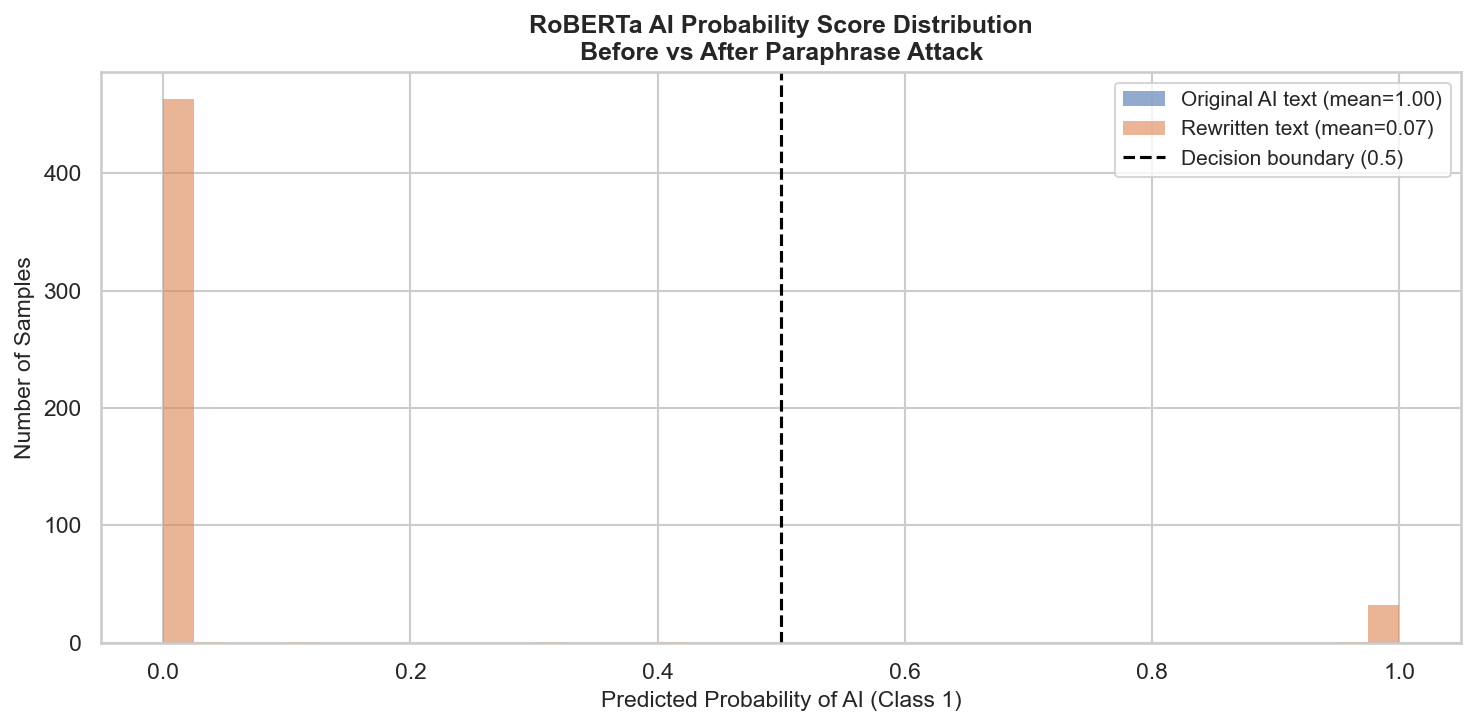

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(adv_df['original_ai_probability'], bins=40, alpha=0.6, color='#4C72B0',
        label=f'Original AI text (mean={adv_df["original_ai_probability"].mean():.2f})',
        edgecolor='none')
ax.hist(adv_df['ai_probability'], bins=40, alpha=0.6, color='#DD8452',
        label=f'Rewritten text (mean={adv_df["ai_probability"].mean():.2f})',
        edgecolor='none')

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5,
           label='Decision boundary (0.5)')

ax.set_title('RoBERTa AI Probability Score Distribution\nBefore vs After Paraphrase Attack',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Probability of AI (Class 1)', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()

fig_path = os.path.join(RESULTS_FIGS, 'fig11_probability_distribution.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
print(f'Figure saved: {fig_path}')
plt.show()

## 11. Example Samples — Correctly Detected vs Successfully Evaded

> **DISSERTATION NOTE:** Add 2–3 of these examples to Chapter 5 as a qualitative analysis table.

In [11]:
# Samples where rewriting successfully fooled the classifier
fooled_df = adv_df[adv_df['predicted_label'] == 0].head(3)

# Samples where classifier still detected AI after rewriting
detected_df = adv_df[adv_df['predicted_label'] == 1].head(3)

print('=== EXAMPLES: Rewriting FOOLED the classifier (predicted: Human) ===')
for i, row in fooled_df.iterrows():
    print(f'\n--- Example {i+1} ---')
    print(f'ORIGINAL  (AI prob={row["original_ai_probability"]:.3f}): {row["original_text"][:200]}')
    print(f'REWRITTEN (AI prob={row["ai_probability"]:.3f}):  {row["rewritten_text"][:200]}')

print('\n=== EXAMPLES: Classifier STILL DETECTED AI after rewriting ===')
for i, row in detected_df.iterrows():
    print(f'\n--- Example {i+1} ---')
    print(f'ORIGINAL  (AI prob={row["original_ai_probability"]:.3f}): {row["original_text"][:200]}')
    print(f'REWRITTEN (AI prob={row["ai_probability"]:.3f}):  {row["rewritten_text"][:200]}')

=== EXAMPLES: Rewriting FOOLED the classifier (predicted: Human) ===

--- Example 1 ---
ORIGINAL  (AI prob=1.000): Serotonin and dopamine are chemicals that are produced by your brain and nervous system. They are involved in many different functions in the body, including mood, sleep, appetite, and pleasure. While
REWRITTEN (AI prob=0.000):  Serotonin and Dopamine are chemicals produced by the brain and the nervous system and are involved in many different functions in the body, including mood, sleep, appetite, and pleasure . While seroto

--- Example 2 ---
ORIGINAL  (AI prob=1.000): Kamikaze pilots were Japanese pilots who flew their airplanes into enemy ships during World War II. They did this as a way to try and sink the enemy ships and protect their own country. The Japanese g
REWRITTEN (AI prob=0.000):  Kamikaze pilots were Japanese pilots that flew their airplanes into enemy ships during World War II to try and sink enemy ships and protect their own country, and many Japanese peo

## 12. Save All Results

In [12]:
adversarial_results = {
    'condition'            : 'adversarial_paraphrase',
    'n_samples'            : len(adv_df),
    'paraphraser'          : 'Vamsi/T5_Paraphrase_Paws',
    'original_detection_rate'  : round(orig_detection,  4),
    'rewritten_detection_rate' : round(rew_detection,   4),
    'original_fooled_rate'     : round(orig_fooled,     4),
    'rewritten_fooled_rate'    : round(rew_fooled,      4),
    'detection_rate_drop_pp'   : round(detection_drop * 100, 2),
    'relative_drop_pct'        : round(relative_drop,  2),
    'original_mean_ai_prob'    : round(float(adv_df['original_ai_probability'].mean()), 4),
    'rewritten_mean_ai_prob'   : round(float(adv_df['ai_probability'].mean()),          4),
}

adv_json_path = os.path.join(RESULTS_METRICS, 'results_adversarial.json')
with open(adv_json_path, 'w') as f:
    json.dump(adversarial_results, f, indent=2)

# Save full predictions
preds_path = os.path.join(RESULTS_METRICS, 'predictions_adversarial.csv')
adv_df.to_csv(preds_path, index=False)

print('All adversarial results saved.')
print(f'  JSON  : {adv_json_path}')
print(f'  Preds : {preds_path}')
print()
print(json.dumps(adversarial_results, indent=2))

All adversarial results saved.
  JSON  : c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\metrics\results_adversarial.json
  Preds : c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\metrics\predictions_adversarial.csv

{
  "condition": "adversarial_paraphrase",
  "n_samples": 500,
  "paraphraser": "Vamsi/T5_Paraphrase_Paws",
  "original_detection_rate": 1.0,
  "rewritten_detection_rate": 0.066,
  "original_fooled_rate": 0.0,
  "rewritten_fooled_rate": 0.934,
  "detection_rate_drop_pp": 93.4,
  "relative_drop_pct": 93.4,
  "original_mean_ai_prob": 1.0,
  "rewritten_mean_ai_prob": 0.0676
}


## 13. Notebook Summary

### Core Finding
The paraphrase attack **reduced AI detection rate** from the original level down to the post-attack level.  
This means the attack successfully caused the classifier to misclassify a significant proportion of AI-generated text as human-written.

### What this means for the dissertation
This directly answers the research question: **paraphrasing rewriting attacks do reduce RoBERTa's detection accuracy**, revealing a significant robustness limitation of supervised transformer-based detectors.

### Files produced
| File | Location | Dissertation use |
|------|----------|------------------|
| `fig09_confusion_matrix_adversarial.png` | `results/figures/` | Figure 9 — Chapter 5 |
| `fig10_attack_impact_barchart.png` | `results/figures/` | Figure 10 — Chapter 5 |
| `fig11_probability_distribution.png` | `results/figures/` | Figure 11 — Chapter 5 |
| `table05_adversarial_comparison.csv` | `results/tables/` | Table 5 — Chapter 5 |
| `results_adversarial.json` | `results/metrics/` | Input for final summary |

### Next step
**Notebook 07:** `07_human_eval_analysis.ipynb` — Analyse Google Forms human evaluation responses.